#Deep Learning-based Fake News Classification using RNN, LSTM, and Pretrained Word Embeddings (GloVe)
### 6CS012 Final Portfolio Project 2026
**Student Name:** Luniva Shrestha
**Student ID:** 2408028
**Date:** May 2026

---
## 0. Install Dependencies

In [1]:
# Run this cell first — restart runtime if prompted
!pip install numpy==1.23.5 -q
!pip install gensim -q
!pip install wordcloud -q
!pip install contractions -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 50.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.7 MB/s eta 0:00:00


---
## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions
from wordcloud import WordCloud
from collections import Counter

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Gensim Word2Vec
import gensim.downloader as api
from google.colab import drive


# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
drive.mount("/content/drive")

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Mounted at /content/drive
All libraries imported successfully!
TensorFlow version: 2.20.0


---
## 2. Load Dataset

In [3]:
import pandas as pd

url = '/content/drive/MyDrive/AL and ML/Final Portfolio Project/Natural Language Processing Task/10.True vs. Fake News Dataset/truevsfakenews.csv'

df = pd.read_csv(url, encoding='latin-1')

# check structure first
print(df.columns)

# choose correct columns (most likely case)
df = df[['text', 'label']]

print(f"Dataset shape: {df.shape}")
df.head(10)

Index(['text', 'label'], dtype='object')
Dataset shape: (20000, 2)


,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake
3,Donald Trump is desperate to stop the investig...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true
5,WASHINGTON (Reuters) - Democratic state offici...,true
6,WASHINGTON (Reuters) - President Donald Trump ...,true
7,Star Wars icon Mark Hamill previously mocked D...,fake
8,WASHINGTON (Reuters) - The U.S. House of Repre...,true
9,The GOP has obstructed President Obama at ever...,fake


DATASET INFORMATION

Total samples : 20000
Missing values:
text     0
label    0
dtype: int64

Class Distribution:
label
true    10000
fake    10000
Name: count, dtype: int64

Class Balance (%)
label
true    50.0
fake    50.0
Name: proportion, dtype: float64


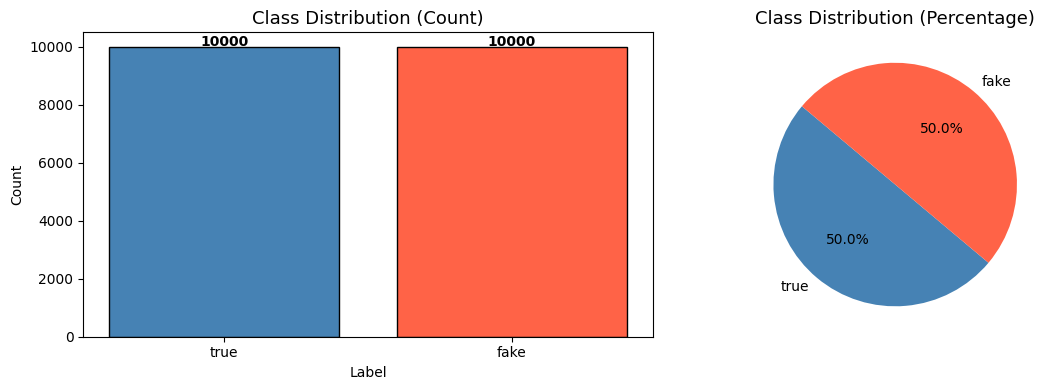

In [4]:
# Basic info and class distribution
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
print(f"\nTotal samples : {len(df)}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nClass Distribution:")
print(df['label'].value_counts())
print(f"\nClass Balance (%)")
print(df['label'].value_counts(normalize=True) * 100)

# Visualise class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=140)
axes[1].set_title('Class Distribution (Percentage)', fontsize=13)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Text Preprocessing

In [5]:
# ---------------------------------------------------------------
# Text Cleaning Function
# Steps: lowercase → expand contractions → remove URLs/mentions/
#        hashtags/numbers/special chars → remove stopwords → lemmatize
# ---------------------------------------------------------------

lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text):
    """Full text cleaning pipeline."""
    # 1. Lowercase
    text = text.lower()

    # 2. Expand contractions  (e.g. "don't" → "do not")
    text = contractions.fix(text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 4. Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # 5. Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # 6. Remove #hashtags
    text = re.sub(r'#\w+', '', text)

    # 7. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 8. Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', ' ', text)

    # 9. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 10. Tokenise, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 1]

    return ' '.join(tokens)


# Apply cleaning
print("Cleaning text data...")
df['cleaned_text'] = df['text'].apply(clean_text)
print("Done!")

# Show before / after examples
print("\n" + "=" * 60)
print("SAMPLE: ORIGINAL vs CLEANED TEXT")
print("=" * 60)
for i in range(3):
    print(f"\nSample {i+1} [{df['label'].iloc[i].upper()}]:")
    print(f"  Original : {df['text'].iloc[i]}")
    print(f"  Cleaned  : {df['cleaned_text'].iloc[i]}")

Cleaning text data...
Done!

SAMPLE: ORIGINAL vs CLEANED TEXT

Sample 1 [TRUE]:
  Original : WASHINGTON (Reuters) - The Republican and Democratic leaders of the U.S. Senate Foreign Relations Committee blasted the U.S. State Department on Tuesday for cuts in staff and what they described as a failure to have a plan for a proposed reorganization. âI donât think they are anywhere close to having a plan to present relative to the reforms that they want,â said Senator Bob Corker, the Republican chairman of the committee. Rex Tillerson, Republican President Donald Trumpâs Secretary of State, has embraced the White Houseâs proposal - rejected by key members of Congress - to cut the State Department budget by about 30 percent. He has imposed a hiring freeze while analyzing the agencyâs operations and deciding how to reorganize them. Tillerson, a former chief executive at Exxon Mobil Corp who took office on Feb. 1, has offered few specifics to ease concerns, including in Congress, t

### 3.1 Visualise Cleaned Data

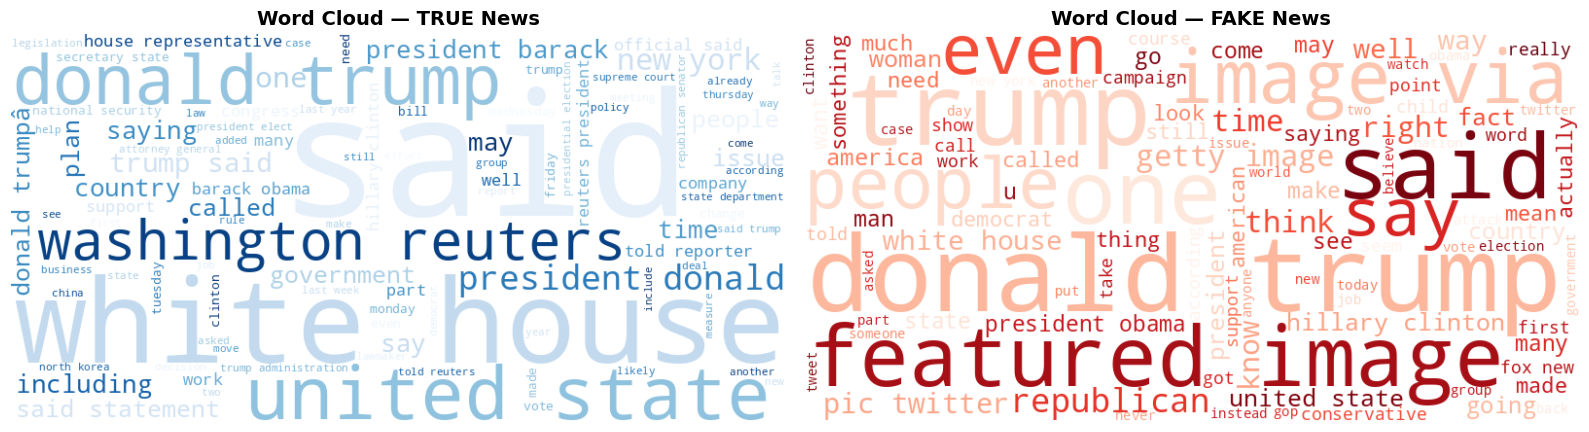

In [6]:
# ---------------------------------------------------------------
# Word Clouds — True vs Fake News
# ---------------------------------------------------------------

true_text = ' '.join(df[df['label'] == 'true']['cleaned_text'])
fake_text = ' '.join(df[df['label'] == 'fake']['cleaned_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_true = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Blues',
    max_words=100
).generate(true_text)

axes[0].imshow(wc_true, interpolation='bilinear')
axes[0].set_title('Word Cloud — TRUE News', fontsize=14, fontweight='bold')
axes[0].axis('off')

wc_fake = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(fake_text)

axes[1].imshow(wc_fake, interpolation='bilinear')
axes[1].set_title('Word Cloud — FAKE News', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_true_fake.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print(df['label'].unique())

['true' 'fake']


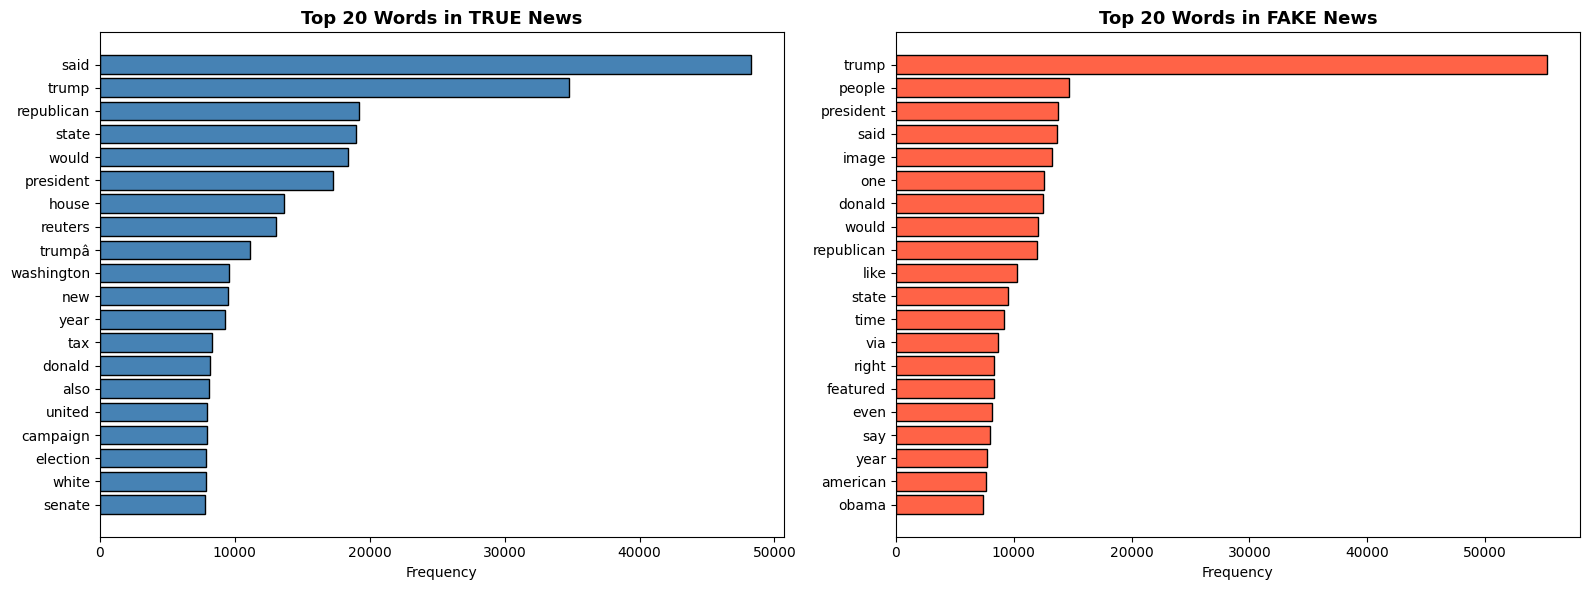

In [7]:
# ---------------------------------------------------------------
# Top 20 Most Frequent Words — True vs Fake News
# ---------------------------------------------------------------

def top_words(texts, n=20):
    all_words = ' '.join(texts).split()
    return Counter(all_words).most_common(n)

true_top = top_words(df[df['label'] == 'true']['cleaned_text'])
fake_top = top_words(df[df['label'] == 'fake']['cleaned_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, color, title in [
    (axes[0], true_top, 'steelblue', 'Top 20 Words in TRUE News'),
    (axes[1], fake_top, 'tomato', 'Top 20 Words in FAKE News')
]:
    words, counts = zip(*data)
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_true_fake.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Tokenisation, Label Encoding, and Padding

Training samples : 16000
Testing samples  : 4000

Vocabulary size : 61350 unique tokens
Using top       : 10001 tokens

Sequence length stats (train):
Mean   : 241.4
Median : 224.0
Max    : 2481
Using fixed MAX_LEN = 300


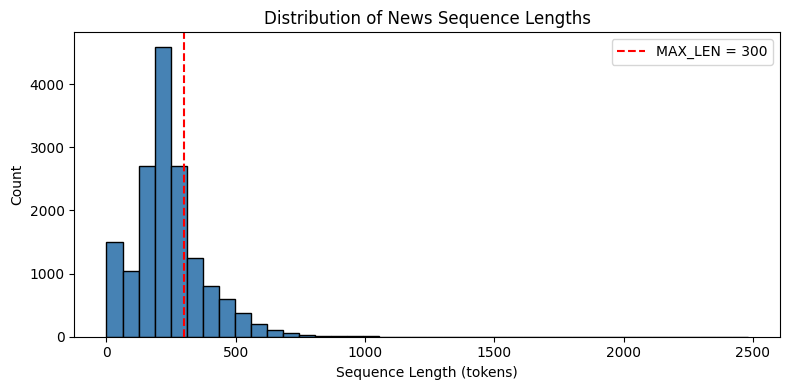


Padded train shape : (16000, 300)
Padded test shape  : (4000, 300)


In [8]:
# ---------------------------------------------------------------
# Encode labels: fake → 0, true → 1
# ---------------------------------------------------------------
df['label_enc'] = df['label'].map({
    'fake': 0,
    'true': 1
})

X = df['cleaned_text'].values
y = df['label_enc'].values

# ---------------------------------------------------------------
# Train / Test Split (80 / 20)
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

# ---------------------------------------------------------------
# Tokenisation with Keras Tokenizer
# ---------------------------------------------------------------
MAX_VOCAB = 10000

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index
vocab_size = min(MAX_VOCAB, len(word_index)) + 1

print(f"\nVocabulary size : {len(word_index)} unique tokens")
print(f"Using top       : {vocab_size} tokens")

# Convert text → sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# ---------------------------------------------------------------
# Sequence length analysis
# ---------------------------------------------------------------
seq_lengths = [len(s) for s in X_train_seq]

print(f"\nSequence length stats (train):")
print(f"Mean   : {np.mean(seq_lengths):.1f}")
print(f"Median : {np.median(seq_lengths):.1f}")
print(f"Max    : {max(seq_lengths)}")

# Better fixed length for news articles
MAX_LEN = 300
print(f"Using fixed MAX_LEN = {MAX_LEN}")

# Visualise sequence lengths
plt.figure(figsize=(8, 4))
plt.hist(seq_lengths, bins=40, color='steelblue', edgecolor='black')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN = {MAX_LEN}')
plt.title('Distribution of News Sequence Lengths')
plt.xlabel('Sequence Length (tokens)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('news_seq_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------
# Padding
# ---------------------------------------------------------------
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print(f"\nPadded train shape : {X_train_pad.shape}")
print(f"Padded test shape  : {X_test_pad.shape}")

---
## 5. Model Building
### Model 1 — Simple RNN with Trainable Embedding

In [9]:
EMBEDDING_DIM = 64

# ---------------------------------------------------------------
# MODEL 1: Simple RNN for Fake News Detection
# ---------------------------------------------------------------
tf.random.set_seed(42)

rnn_model = Sequential(name='SimpleRNN_Model')

# Input layer
rnn_model.add(Input(shape=(MAX_LEN,)))

# Embedding layer
rnn_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM
    )
)

# RNN layer
rnn_model.add(SimpleRNN(64, return_sequences=False))

# Dense layers
rnn_model.add(Dropout(0.3))
rnn_model.add(Dense(32, activation='relu'))
rnn_model.add(Dropout(0.3))

# Binary output: fake(0) / true(1)
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 64)        │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,433 (2.48 MB)

 Trainable params: 650,433 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

### Model 2 — LSTM with Trainable Embedding

In [10]:
tf.random.set_seed(42)

lstm_model = Sequential(name='LSTM_Model')

# Input layer
lstm_model.add(Input(shape=(MAX_LEN,)))

# Embedding layer (for text input)
lstm_model.add(Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM))

# LSTM layer
lstm_model.add(LSTM(64))

# Regularization
lstm_model.add(Dropout(0.3))

# Fully connected layer
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dropout(0.3))

# Output layer (binary classification: fake=0, true=1)
lstm_model.add(Dense(1, activation='sigmoid'))

# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 64)        │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,201 (2.58 MB)

 Trainable params: 675,201 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

### Model 3 — LSTM with Pretrained GloVe / Word2Vec Embeddings

In [13]:
# ---------------------------------------------------------------
# STEP 1: Load pretrained GloVe embeddings (50-dim)
# ---------------------------------------------------------------
print("Loading pretrained GloVe embeddings (glove-wiki-gigaword-50)...")
embedding_model = api.load('glove-wiki-gigaword-50')
print("Loaded!")

GLOVE_DIM = 50

# ---------------------------------------------------------------
# STEP 2: Build embedding matrix
# ---------------------------------------------------------------
embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))

found, not_found = 0, 0

word_index = tokenizer.word_index

for word, idx in word_index.items():
    if idx >= vocab_size:
        continue

    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        found += 1
    else:
        not_found += 1

coverage = found / (found + not_found) * 100

print(f"\nEmbedding matrix shape : {embedding_matrix.shape}")
print(f"Words found in GloVe   : {found}")
print(f"Words NOT found        : {not_found}")
print(f"Vocabulary coverage    : {coverage:.1f}%")

Loading pretrained GloVe embeddings (glove-wiki-gigaword-50)...
Loaded!

Embedding matrix shape : (10001, 50)
Words found in GloVe   : 9692
Words NOT found        : 308
Vocabulary coverage    : 96.9%


In [14]:
tf.random.set_seed(42)

lstm_w2v_model = Sequential(name='LSTM_GloVe_Model')

lstm_w2v_model.add(Input(shape=(MAX_LEN,)))

lstm_w2v_model.add(Embedding(
    input_dim=vocab_size,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],
    trainable=False,
    mask_zero=True
))

lstm_w2v_model.add(LSTM(64))
lstm_w2v_model.add(Dropout(0.3))

lstm_w2v_model.add(Dense(32, activation='relu'))
lstm_w2v_model.add(Dropout(0.3))

lstm_w2v_model.add(Dense(1, activation='sigmoid'))

lstm_w2v_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_w2v_model.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 300, 50)        │       500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,603 (2.03 MB)

 Trainable params: 31,553 (123.25 KB)

 Non-trainable params: 500,050 (1.91 MB)

---
## 6. Model Training

In [15]:
# ---------------------------------------------------------------
# Shared training settings
# ---------------------------------------------------------------
EPOCHS     = 20
BATCH_SIZE = 64

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [16]:
# ---------------------------------------------------------------
# Train Model 1: Simple RNN
# ---------------------------------------------------------------
print("Training Model 1 — Simple RNN...")
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Training Model 1 — Simple RNN...
Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - accuracy: 0.6279 - loss: 0.6444 - val_accuracy: 0.6662 - val_loss: 0.6233
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.5376 - loss: 0.6989 - val_accuracy: 0.7138 - val_loss: 0.6179
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.5728 - loss: 0.6823 - val_accuracy: 0.7631 - val_loss: 0.5812
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 96ms/step - accuracy: 0.6434 - loss: 0.6395 - val_accuracy: 0.6081 - val_loss: 0.6591
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.8568 - loss: 0.3851 - val_accuracy: 0.9425 - val_loss: 0.1860
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - accuracy: 0.8322 - loss: 0.4149 - val_accuracy: 0.9112 - val_loss: 0.3129
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - accuracy: 0.6615 - loss: 0.5970 - val_accuracy: 0.6150 - val_loss: 0.6024
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - 

In [17]:
# ---------------------------------------------------------------
# Train Model 2: LSTM
# ---------------------------------------------------------------
print("Training Model 2 — LSTM...")
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Training Model 2 — LSTM...
Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 47s 195ms/step - accuracy: 0.6707 - loss: 0.5659 - val_accuracy: 0.9281 - val_loss: 0.2291
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 44s 197ms/step - accuracy: 0.9122 - loss: 0.2802 - val_accuracy: 0.8819 - val_loss: 0.3046
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 44s 196ms/step - accuracy: 0.7806 - loss: 0.4299 - val_accuracy: 0.5806 - val_loss: 0.6848
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [18]:
# ---------------------------------------------------------------
# Train Model 3: LSTM + GloVe
# ---------------------------------------------------------------
print("Training Model 3 — LSTM + GloVe...")
history_w2v = lstm_w2v_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Training Model 3 — LSTM + GloVe...
Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 186ms/step - accuracy: 0.9147 - loss: 0.2381 - val_accuracy: 0.9613 - val_loss: 0.1136
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 41s 183ms/step - accuracy: 0.9547 - loss: 0.1426 - val_accuracy: 0.9488 - val_loss: 0.1325
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 42s 185ms/step - accuracy: 0.9541 - loss: 0.1377 - val_accuracy: 0.9500 - val_loss: 0.1453
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 83s 189ms/step - accuracy: 0.9586 - loss: 0.1225 - val_accuracy: 0.9706 - val_loss: 0.0954
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 82s 190ms/step - accuracy: 0.9691 - loss: 0.0913 - val_accuracy: 0.9769 - val_loss: 0.0769
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 44s 196ms/step - accuracy: 0.9695 - loss: 0.0905 - val_accuracy: 0.9725 - val_loss: 0.0876
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 43s 189ms/step - accuracy: 0.9578 - loss: 0.1064 - val_accuracy: 0.9712 - val_loss: 0.0760
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 43s 189m

---
## 7. Training Visualisation

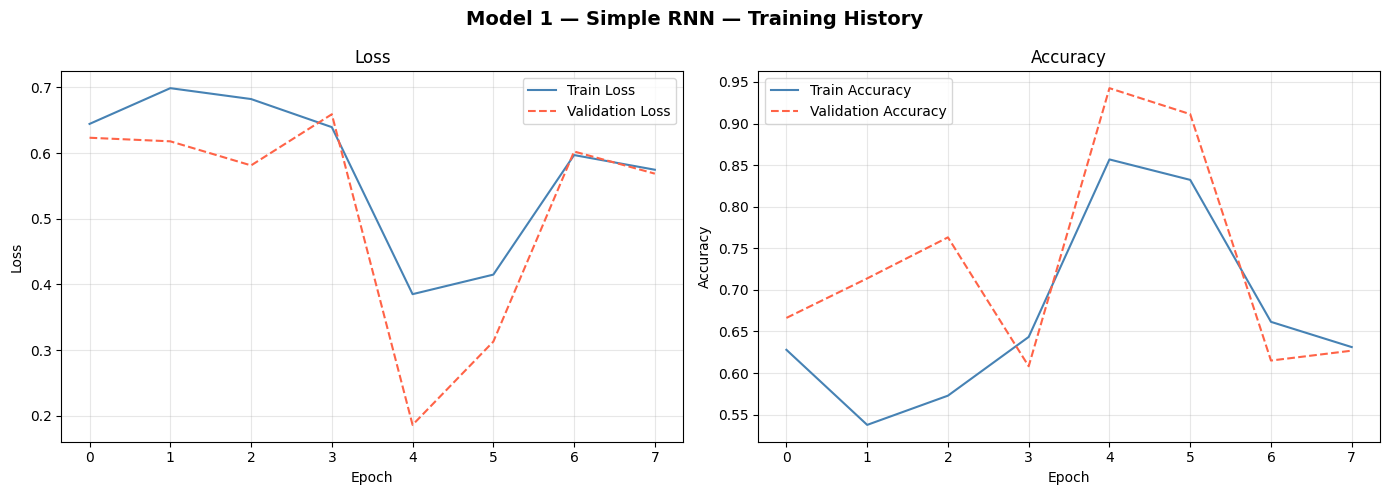

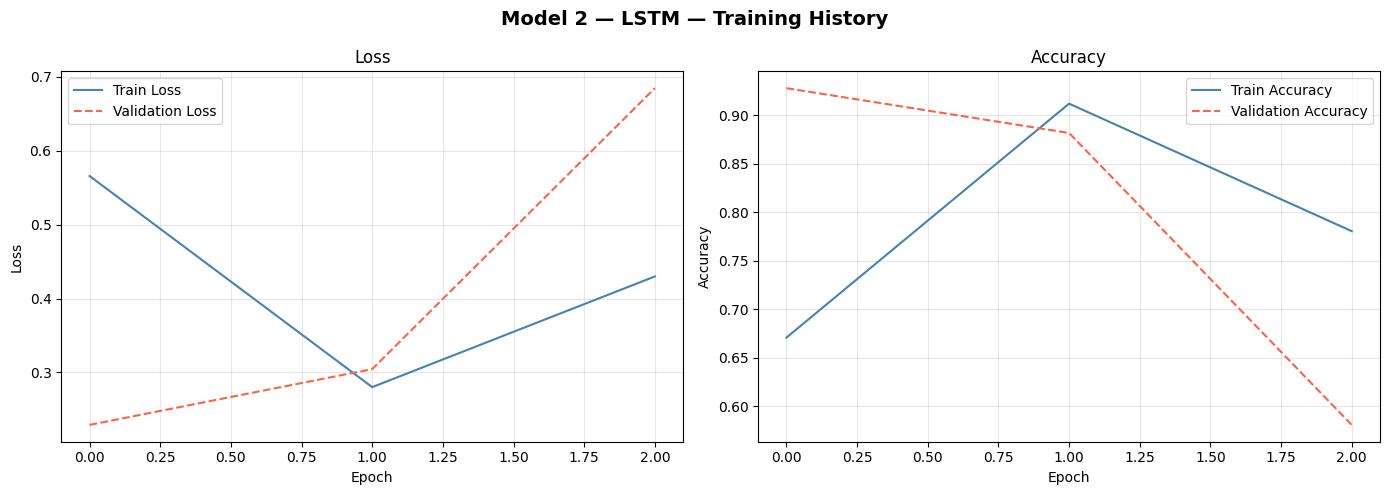

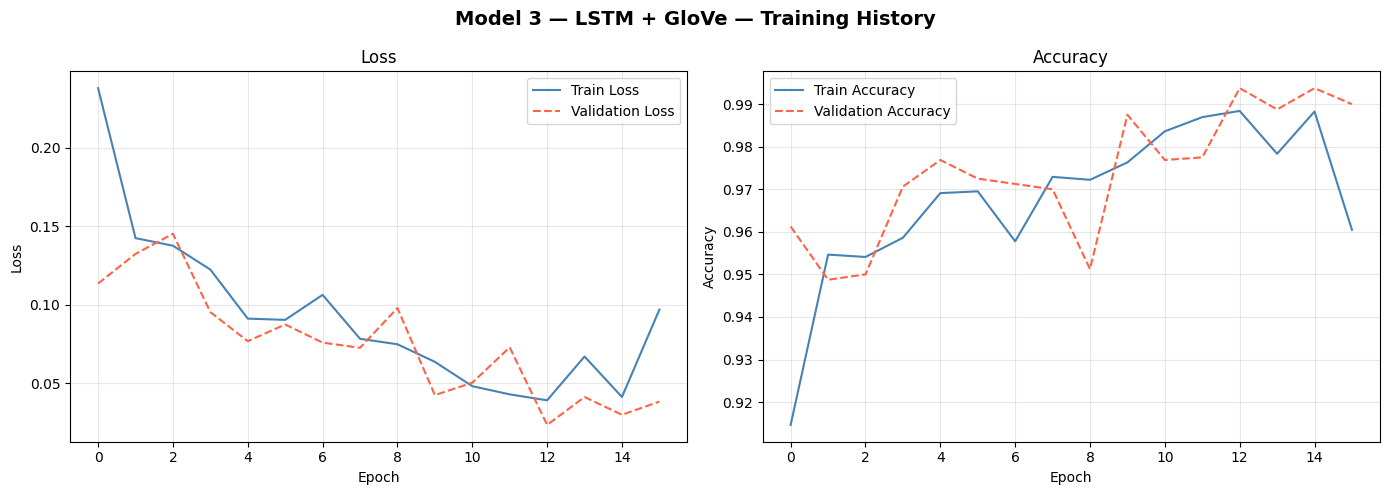

In [19]:
# ---------------------------------------------------------------
# Helper: plot training/validation loss and accuracy
# ---------------------------------------------------------------
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Training History', fontsize=14, fontweight='bold')

    # Loss
    axes[0].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
    axes[0].plot(history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato', linestyle='--')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    fname = model_name.replace(' ', '_').lower() + '_history.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


plot_history(history_rnn,  'Model 1 — Simple RNN')
plot_history(history_lstm, 'Model 2 — LSTM')
plot_history(history_w2v,  'Model 3 — LSTM + GloVe')

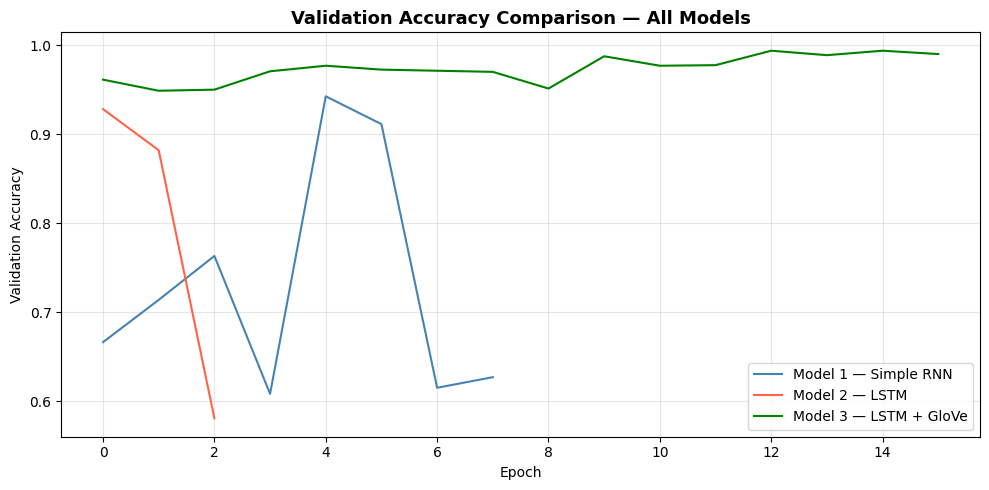

In [20]:
# ---------------------------------------------------------------
# Compare all 3 models — Validation accuracy on same plot
# ---------------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(history_rnn.history['val_accuracy'],  label='Model 1 — Simple RNN',   color='steelblue')
plt.plot(history_lstm.history['val_accuracy'], label='Model 2 — LSTM',         color='tomato')
plt.plot(history_w2v.history['val_accuracy'],  label='Model 3 — LSTM + GloVe', color='green')

plt.title('Validation Accuracy Comparison — All Models', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Model Evaluation


  Model 1 — Simple RNN
  Test Accuracy : 94.42%

  Classification Report:
              precision    recall  f1-score   support

         True       0.96      0.93      0.94      2000
        Fake       0.93      0.96      0.95      2000

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000



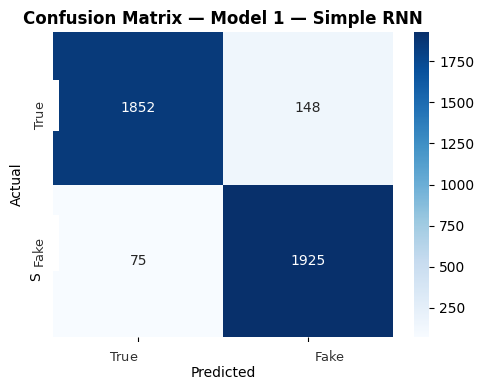


  Model 2 — LSTM
  Test Accuracy : 92.70%

  Classification Report:
              precision    recall  f1-score   support

         True       0.99      0.86      0.92      2000
        Fake       0.88      0.99      0.93      2000

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000



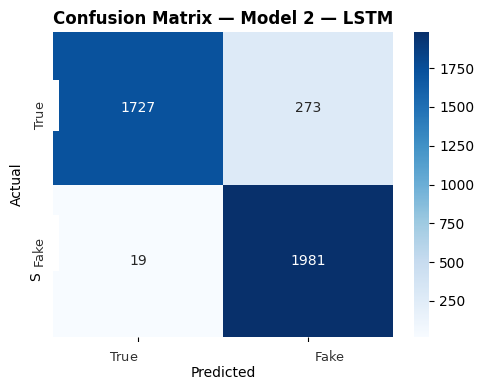


  Model 3 — LSTM + GloVe
  Test Accuracy : 98.55%

  Classification Report:
              precision    recall  f1-score   support

         True       0.99      0.98      0.99      2000
        Fake       0.98      0.99      0.99      2000

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



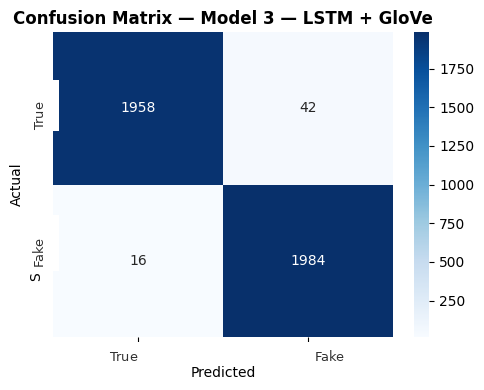

In [21]:
# ---------------------------------------------------------------
# Evaluate all models on the test set
# ---------------------------------------------------------------

def evaluate_model(model, X_test, y_test, model_name):
    """Prints accuracy, classification report and plots confusion matrix."""
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred)

    print("\n" + "=" * 60)
    print(f"  {model_name}")
    print("=" * 60)
    print(f"  Test Accuracy : {acc * 100:.2f}%")
    print("\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['True', 'Fake']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['True', 'Fake'],
                yticklabels=['True', 'Fake'])
    plt.title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    fname = model_name.replace(' ', '_').replace('—', '').lower() + '_cm.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    return acc, y_pred


acc_rnn,  y_pred_rnn  = evaluate_model(rnn_model,      X_test_pad, y_test, 'Model 1 — Simple RNN')
acc_lstm, y_pred_lstm = evaluate_model(lstm_model,     X_test_pad, y_test, 'Model 2 — LSTM')
acc_w2v,  y_pred_w2v  = evaluate_model(lstm_w2v_model, X_test_pad, y_test, 'Model 3 — LSTM + GloVe')

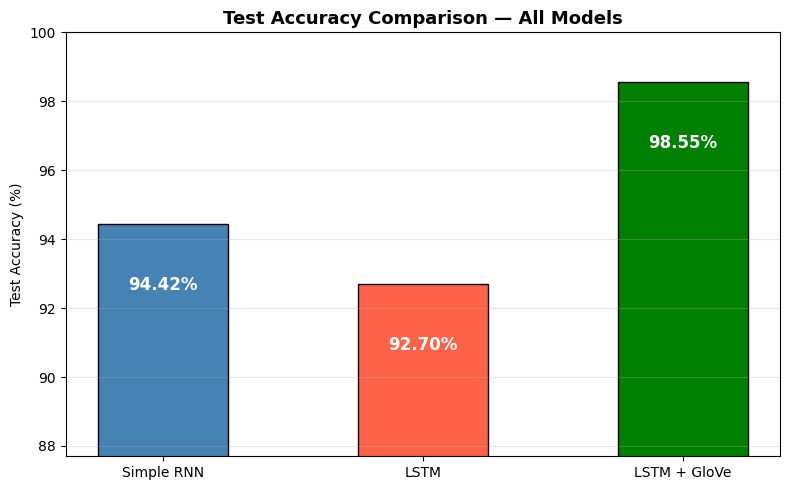


Summary Table:
       Model Test Accuracy (%)
  Simple RNN             94.42
        LSTM             92.70
LSTM + GloVe             98.55


In [22]:
# ---------------------------------------------------------------
# Summary bar chart — Test Accuracy
# ---------------------------------------------------------------
model_names = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
accuracies  = [acc_rnn * 100, acc_lstm * 100, acc_w2v * 100]
colors      = ['steelblue', 'tomato', 'green']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() - 1.5,
             f'{acc:.2f}%', ha='center', va='top', fontweight='bold', color='white', fontsize=12)
plt.ylim(min(accuracies) - 5, 100)
plt.title('Test Accuracy Comparison — All Models', fontsize=13, fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSummary Table:")
summary_df = pd.DataFrame({'Model': model_names, 'Test Accuracy (%)': [f'{a:.2f}' for a in accuracies]})
print(summary_df.to_string(index=False))

---
## 9. Error Analysis

In [27]:
# ---------------------------------------------------------------
# Error Analysis — using best model (LSTM + GloVe, Model 3)
# ---------------------------------------------------------------

import pandas as pd

# Reconstruct test set for analysis
test_df = pd.DataFrame({
    'original_text': X_test,
    'true_label': ['true' if l == 1 else 'fake' for l in y_test],
    'pred_label_m3': ['true' if l == 1 else 'fake' for l in y_pred_w2v],
    'pred_label_m1': ['true' if l == 1 else 'fake' for l in y_pred_rnn],
    'pred_label_m2': ['true' if l == 1 else 'fake' for l in y_pred_lstm],
})

# Misclassified by best model (Model 3)
misclassified = test_df[test_df['true_label'] != test_df['pred_label_m3']].reset_index(drop=True)

print(f"Total misclassified by Model 3 (LSTM + GloVe): {len(misclassified)} / {len(test_df)}")
print(f"Error rate: {len(misclassified)/len(test_df)*100:.2f}%")

print("\n" + "=" * 70)
print("INCORRECT PREDICTION EXAMPLES")
print("=" * 70)

# Show 3 misclassified examples
for i, row in misclassified.head(3).iterrows():
    print(f"\nExample {i+1}:")
    print(f"  Text           : {row['original_text']}")
    print(f"  True Label     : {row['true_label'].upper()}")
    print(f"  Predicted      : {row['pred_label_m3'].upper()}")

    error_type = (
        "False Positive (True → Fake)" if row['true_label'] == 'true'
        else "False Negative (Fake → True)"
    )

    print(f"  Error Type     : {error_type}")

Total misclassified by Model 3 (LSTM + GloVe): 58 / 4000
Error rate: 1.45%

INCORRECT PREDICTION EXAMPLES

Example 1:
  Text           : hillary clinton praised london socialized medicine fall stair sent hospital examination came wearing boot foot say broke toe hummmbut wait communication director nick merrill tweeted said twisted ankle call b hrc graham norton show joking caught heel step twisted ankle earlier today back book tour pic twitter com fkhljnat nick merrill october anyone really believe hillary clinton make three appearance fell stair detail say really never wear heel photo last night show wearing short boot seems something else going besides simple broken toe could hillary getting pushback expect interviewer bristled visibly irritated asked wikileaks interview yesterday australian tv see buying one medium say clinton cancellation interview london washington examiner reported hillary clinton canceled several medium appearance monday book tour london fell stair broke toe run

In [28]:
# ---------------------------------------------------------------
# Error Type Breakdown
# ---------------------------------------------------------------

false_positives = misclassified[misclassified['true_label'] == 'true']   # true → fake
false_negatives = misclassified[misclassified['true_label'] == 'fake']   # fake → true

print(f"False Positives (True predicted as Fake) : {len(false_positives)}")
print(f"False Negatives (Fake predicted as True) : {len(false_negatives)}")

print("""
POSSIBLE REASONS FOR MISCLASSIFICATION:
  1. Ambiguous language: Some news articles contain mixed signals
     (partly true, partly misleading), making classification difficult.
  2. Long or noisy text: Very long articles may dilute important signals
     after padding/truncation.
  3. Unseen vocabulary: Words not present in GloVe embeddings are ignored
     or weakly represented, reducing semantic understanding.
  4. Dataset bias: If dataset is imbalanced (e.g., more "true" than "fake"),
     the model may lean toward majority class.
  5. Context limitation: LSTM models still struggle with deep factual reasoning
     required for fake news detection.

POTENTIAL IMPROVEMENTS:
  - Apply class weights to handle imbalance.
  - Use Bidirectional LSTM (captures both directions of context).
  - Fine-tune embeddings (set trainable=True instead of freezing GloVe).
  - Try attention mechanism or Transformer-based models (e.g., BERT).
  - Improve preprocessing (remove noise, better tokenization).
  - Tune hyperparameters (LSTM units, dropout, learning rate, batch size).
""")

False Positives (True predicted as Fake) : 16
False Negatives (Fake predicted as True) : 42

POSSIBLE REASONS FOR MISCLASSIFICATION:
  1. Ambiguous language: Some news articles contain mixed signals
     (partly true, partly misleading), making classification difficult.
  2. Long or noisy text: Very long articles may dilute important signals
     after padding/truncation.
  3. Unseen vocabulary: Words not present in GloVe embeddings are ignored
     or weakly represented, reducing semantic understanding.
  4. Dataset bias: If dataset is imbalanced (e.g., more "true" than "fake"),
     the model may lean toward majority class.
  5. Context limitation: LSTM models still struggle with deep factual reasoning
     required for fake news detection.

POTENTIAL IMPROVEMENTS:
  - Apply class weights to handle imbalance.
  - Use Bidirectional LSTM (captures both directions of context).
  - Fine-tune embeddings (set trainable=True instead of freezing GloVe).
  - Try attention mechanism or Transfo

---
## 10. Real-Time Prediction GUI (Gradio)
 Run this cell to launch an interactive web interface.

In [25]:
!pip install gradio -q

In [29]:
import gradio as gr

def predict_fake_news(message):
    """Classify a single news article using all three models."""

    if not message.strip():
        return "Please enter a news text."

    # Preprocess input
    cleaned  = clean_text(message)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    # Predictions from all models
    p1 = rnn_model.predict(padded, verbose=0)[0][0]
    p2 = lstm_model.predict(padded, verbose=0)[0][0]
    p3 = lstm_w2v_model.predict(padded, verbose=0)[0][0]

    def label(p):
        return f"{'🚨 FAKE' if p < 0.5 else '✅ TRUE'} ({(1-p)*100:.1f}% fake probability)"

    return (
        f"**Model 1 — Simple RNN :** {label(p1)}\n\n"
        f"**Model 2 — LSTM       :** {label(p2)}\n\n"
        f"**Model 3 — LSTM+GloVe :** {label(p3)}"
    )


demo = gr.Interface(
    fn=predict_fake_news,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Type or paste a news article here...",
        label="News Text"
    ),
    outputs=gr.Markdown(label="Predictions"),
    title="📰 Fake News Detection System",
    description="Enter a news article and classify it as TRUE or FAKE using three deep learning models.",
    examples=[
        ["The government has announced a new policy to improve education standards nationwide."],
        ["Scientists confirm that drinking water cures all diseases instantly."],
        ["Stock markets rise after positive economic reports from global banks."],
        ["Breaking: Humans will become immortal by 2030, experts say."]
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3c2c697a56821d1f07.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 11. Summary

| Model | Architecture | Embedding | Test Accuracy |
|-------|-------------|-----------|---------------|
| Model 1 | Simple RNN | Trainable | 94.42% |
| Model 2 | LSTM | Trainable | 92.70% |
| Model 3 | LSTM | GloVe (frozen) | 98.55% |

**Key Observations:**
- LSTM models use memory gates (input, forget, output gates), which help capture long-term dependencies in news text.
- Pretrained GloVe embeddings provide better semantic understanding compared to randomly initialized embeddings, especially for rare or unseen words.
- Model 3 (LSTM + GloVe) generally gives more stable and faster convergence, since embeddings already contain semantic structure from large corpora.
- Fake news detection is a binary classification task with semantic ambiguity, making it harder than simple keyword-based classification.